In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve, 
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

import shap
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV


In [3]:
import pandas as pd

df = pd.read_csv("../feature-engineering/output/dataset_churn_features.csv")

print(df.shape)
print(df.columns.tolist())

(500, 14)
['cliente_id', 'total_atendimentos', 'total_gasto', 'ticket_medio', 'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos', 'atendimentos_30d', 'atendimentos_90d', 'gasto_90d', 'quantidade_servicos_diferentes', 'quantidade_profissionais_diferentes', 'target_churn', 'atraso_vs_intervalo_medio', 'atraso_percentual']


In [4]:
features_modelo_a = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d"
]

features_modelo_b = features_modelo_a + [
    "atraso_vs_intervalo_medio",
    "atraso_percentual"
]

In [6]:
X_a = df[features_modelo_a]
y = df["target_churn"]

In [7]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Treinamento:", X_train_a.shape)
print("Teste:", X_test_a.shape)

Treinamento: (400, 8)
Teste: (100, 8)


In [15]:
modelo_a = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_a.fit(X_train_a, y_train_a)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
y_pred_a = modelo_a.predict(X_test_a)

In [12]:
accuracy_a = accuracy_score(y_test_a, y_pred_a)
precision_a = precision_score(y_test_a, y_pred_a)
recall_a = recall_score(y_test_a, y_pred_a)
f1_a = f1_score(y_test_a, y_pred_a)

print("===== MODELO A =====")
print(f"Accuracy : {accuracy_a:.4f}")
print(f"Precision: {precision_a:.4f}")
print(f"Recall   : {recall_a:.4f}")
print(f"F1-score : {f1_a:.4f}")

===== MODELO A =====
Accuracy : 0.7200
Precision: 0.7059
Recall   : 0.3429
F1-score : 0.4615


In [14]:
print(
    classification_report(
        y_test_a,
        y_pred_a,
        target_names=["Não Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

   Não Churn       0.72      0.92      0.81        65
       Churn       0.71      0.34      0.46        35

    accuracy                           0.72       100
   macro avg       0.71      0.63      0.64       100
weighted avg       0.72      0.72      0.69       100



In [16]:
cm_a = confusion_matrix(y_test_a, y_pred_a)

print("===== MATRIZ DE CONFUSÃO =====")
print(cm_a)

===== MATRIZ DE CONFUSÃO =====
[[60  5]
 [23 12]]


#treinar o Modelo B

In [25]:
X_b = df[features_modelo_b]
y_b = df["target_churn"]

In [26]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42,
    stratify=y_b
)

In [19]:
modelo_b = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_b.fit(X_train_b, y_train_b)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [20]:
y_pred_b = modelo_b.predict(X_test_b)

In [21]:
print("===== MODELO B =====")

print(
    classification_report(
        y_test_b,
        y_pred_b,
        target_names=["Não Churn", "Churn"]
    )
)

===== MODELO B =====
              precision    recall  f1-score   support

   Não Churn       0.70      0.95      0.81        65
       Churn       0.73      0.23      0.35        35

    accuracy                           0.70       100
   macro avg       0.71      0.59      0.58       100
weighted avg       0.71      0.70      0.65       100



In [22]:
cm_b = confusion_matrix(y_test_b, y_pred_b)

print("===== MATRIZ DE CONFUSÃO =====")
print(cm_b)

===== MATRIZ DE CONFUSÃO =====
[[62  3]
 [27  8]]


Treinamento modelo C

In [23]:
modelo_c = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo_c.fit(X_train_a, y_train_b)

y_pred_c = modelo_c.predict(X_test_a)

print("===== MODELO C =====")

print(
    classification_report(
        y_test_a,
        y_pred_c,
        target_names=["Não Churn", "Churn"]
    )
)

===== MODELO C =====
              precision    recall  f1-score   support

   Não Churn       0.75      0.51      0.61        65
       Churn       0.43      0.69      0.53        35

    accuracy                           0.57       100
   macro avg       0.59      0.60      0.57       100
weighted avg       0.64      0.57      0.58       100



In [24]:
cm_c = confusion_matrix(y_test_a, y_pred_c)

print("===== MATRIZ DE CONFUSÃO =====")
print(cm_c)

===== MATRIZ DE CONFUSÃO =====
[[33 32]
 [11 24]]


MODELO USANDO PREDICT_PROBA()

In [ ]:
modelo_d = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

modelo_d.fit(X_train_a, y_train_a)

y_prob_d = modelo_d.predict_proba(X_test_a)[:, 1]

threshold = 0.50

y_pred_d = (y_prob_d >= threshold).astype(int)

print("===== MODELO D =====")

print(
    classification_report(
        y_test_a,
        y_pred_d,
        target_names=["Não Churn", "Chunr"]
    )
)

print("===== MATRIZ DE CONFUSÃO =====")

print(confusion_matrix(y_test_a, y_pred_d))


===== MODELO D =====
              precision    recall  f1-score   support

   Não Churn       0.74      0.49      0.59        65
       Chunr       0.42      0.69      0.52        35

    accuracy                           0.56       100
   macro avg       0.58      0.59      0.56       100
weighted avg       0.63      0.56      0.57       100

===== MATRIZ DE CONFUSÃO =====
[[32 33]
 [11 24]]


In [15]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_prob_d >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(
        y_test_a,
        y_pred,
        target_names=["Não Churn", "Churn"]
    ))


Threshold: 0.3
              precision    recall  f1-score   support

   Não Churn       0.75      0.28      0.40        65
       Churn       0.38      0.83      0.52        35

    accuracy                           0.47       100
   macro avg       0.57      0.55      0.46       100
weighted avg       0.62      0.47      0.45       100


Threshold: 0.4
              precision    recall  f1-score   support

   Não Churn       0.76      0.40      0.53        65
       Churn       0.41      0.77      0.53        35

    accuracy                           0.53       100
   macro avg       0.59      0.59      0.53       100
weighted avg       0.64      0.53      0.53       100


Threshold: 0.5
              precision    recall  f1-score   support

   Não Churn       0.74      0.49      0.59        65
       Churn       0.42      0.69      0.52        35

    accuracy                           0.56       100
   macro avg       0.58      0.59      0.56       100
weighted avg       0.63   

## ROC Curve e AUC ##

AUC: 0.6685714285714286


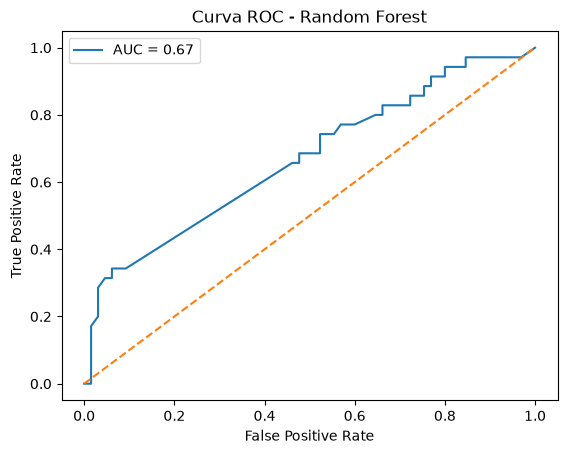

In [18]:
# Criando randoForest
from matplotlib import pyplot as plt


modelo_d = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Treinando o modelo
modelo_d.fit(X_train_a, y_train_a)

# Probabilidades do modelo
y_prob_d = modelo_d.predict_proba(X_test_a)[:, 1]

#ROC
fpr, tpr, thresholds = roc_curve(y_test_a, y_prob_d)

#AUC
auc = roc_auc_score(y_test_a, y_prob_d)

print("AUC:", auc)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()



## Feature Importance do Random Forest.

                         feature  importance
1                    total_gasto    0.201169
2                   ticket_medio    0.178402
7                      gasto_90d    0.171147
3  dias_desde_ultimo_atendimento    0.145261
4   intervalo_medio_atendimentos    0.127743
0             total_atendimentos    0.093573
6               atendimentos_90d    0.058969
5               atendimentos_30d    0.023735


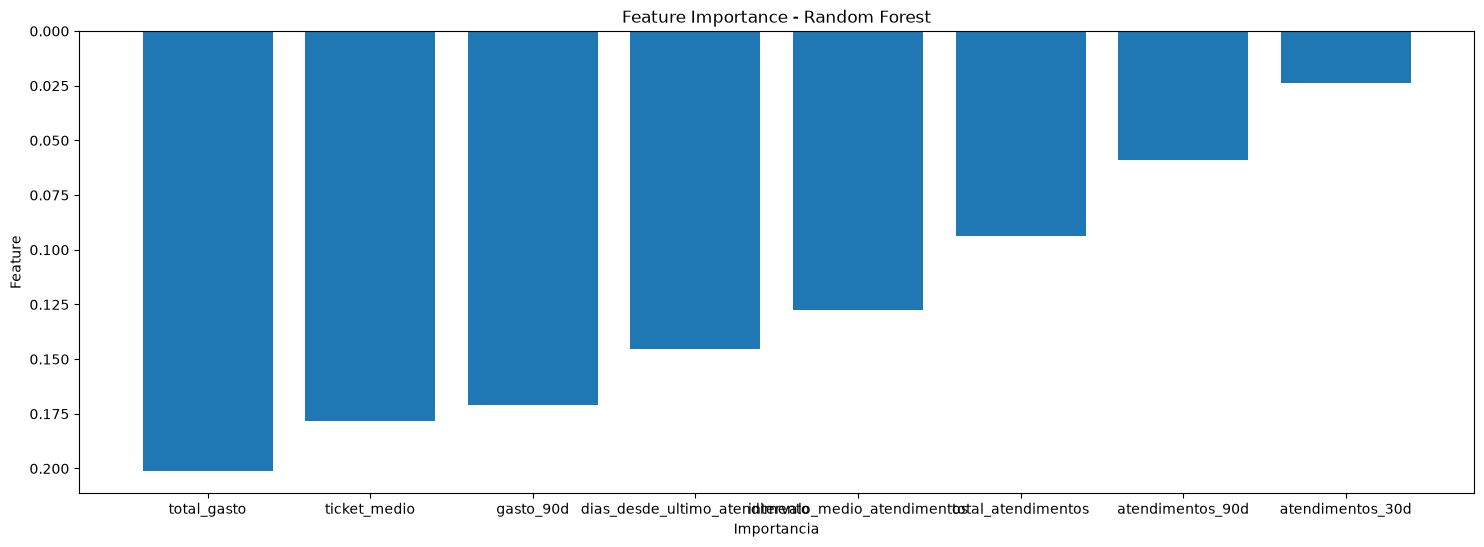

In [28]:
importances = modelo_d.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train_a.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(18, 6))

plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()



O que isso está dizendo sobre o seu modelo?

As 5 primeiras features concentram cerca de 82,4% da importância total:

total_gasto → 20,1%
ticket_medio → 17,8%
gasto_90d → 17,1%
dias_desde_ultimo_atendimento → 14,5%
intervalo_medio_atendimentos → 12,8%

Isso sugere que o modelo está tomando suas decisões principalmente com base em valor financeiro + comportamento de frequência/recência.

## SHAP (SHapley Additive exPlanations)
“por que o modelo considera um cliente como risco de churn?”.

In [33]:
import shap
import matplotlib.pyplot as plt

# Modelo treinado
model = modelo_d

# Dados utilizados pelo modelo
X_shap = X_test_a

# Criar explicador
explainer = shap.TreeExplainer(model)

# Calcular valores SHAP
shap_values = explainer.shap_values(X_shap)

print("Tipo:", type(shap_values))

if isinstance(shap_values, list):
    print("Número de classes:", len(shap_values))
    print("Shape classe 0:", shap_values[0].shape)
    print("Shape classe 1:", shap_values[1].shape)
else:
    print("Shape:", shap_values.shape)

Tipo: <class 'numpy.ndarray'>
Shape: (100, 8, 2)


Shape SHAP churn: (100, 8)


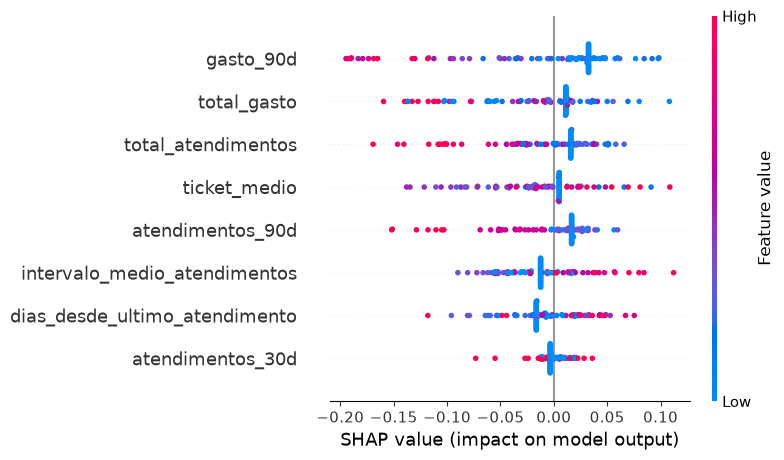

In [34]:
# SHAP da classe 1 = churn
shap_values_churn = shap_values[:, :, 1]

print("Shape SHAP churn:", shap_values_churn.shape)

# Gráfico de importância global
shap.summary_plot(
    shap_values_churn,
    X_shap,
    feature_names=X_shap.columns
)

## Direção do impacto por feature

gasto_90d (gasto nos últimos 90 dias) — impacto mais forte do modelo. Pontos vermelhos (gasto alto) concentram-se fortemente à esquerda (SHAP muito negativo, até -0.20), enquanto pontos azuis (gasto baixo) ficam à direita (SHAP positivo). Ou seja: quanto menos o cliente gastou recentemente, maior o risco de churn.

total_gasto — mesmo padrão: gasto histórico alto reduz o risco; gasto histórico baixo aumenta.

total_atendimentos — clientes com poucos atendimentos acumulados (azul) empurram o SHAP para a direita (mais risco); clientes com histórico robusto de atendimentos (vermelho) reduzem o risco.

ticket_medio — impacto mais fraco e disperso, sem separação clara de cor. Sugere que o valor médio por atendimento, isoladamente, não é um bom preditor de churn neste modelo.

atendimentos_90d — mesmo padrão de gasto_90d: poucos atendimentos recentes (azul) aumentam o risco; muitos atendimentos recentes (vermelho) reduzem.

intervalo_medio_atendimentos — aqui a cor inverte em relação às anteriores: valores altos (vermelho = intervalos longos entre atendimentos) ficam à direita, aumentando o risco. Valores baixos (azul = atendimentos frequentes) reduzem o risco.

dias_desde_ultimo_atendimento — mesmo padrão: quanto mais dias sem aparecer (vermelho), maior o SHAP positivo, ou seja, maior o risco de churn. Clientes que atenderam recentemente (azul) puxam o SHAP para negativo.

atendimentos_30d — mesma lógica das demais features de frequência/gasto: pouca atividade no último mês aumenta o risco.

Quem está em risco e por quê

O padrão é consistente entre quase todas as features: o cliente em risco é aquele que "sumiu" ou desacelerou —

gastou pouco nos últimos 90 dias
teve poucos atendimentos recentes (30 e 90 dias)
tem histórico total de atendimentos/gasto baixo
está há muitos dias sem retornar
tem intervalo médio entre atendimentos longo (comportamento historicamente espaçado, não só recente)

Ou seja, não é só "sumiu agora" — o modelo também pega clientes que nunca tiveram um padrão de recorrência forte (intervalo médio alto e total_atendimentos baixo desde sempre), o que é um sinal de risco estrutural, não só uma queda pontual.

Quem precisa de ação de retenção

Priorizar clientes que combinam múltiplos sinais vermelhos ao mesmo tempo, especialmente nas features mais importantes:

dias_desde_ultimo_atendimento alto + gasto_90d baixo + atendimentos_90d baixo → maior urgência (churn iminente)
intervalo_medio_atendimentos alto, mesmo com atividade recente ok → risco estrutural, precisa de programa de fidelização/recorrência
total_gasto e total_atendimentos baixos, independente do resto → cliente de baixo engajamento histórico, pode precisar de oferta de ativação em vez de retenção pura

## Explicar o churn de um cliente individual.

In [35]:
# Probabilidade de churn para todos os clientes do teste
prob_churn = modelo_a.predict_proba(X_test_a)[:, 1]

# Índice do cliente com maior risco
idx_cliente = prob_churn.argmax()

# Dados do cliente
cliente = X_test_a.iloc[idx_cliente]

# Probabilidade
probabilidade = prob_churn[idx_cliente]

print("Índice do cliente:", idx_cliente)
print(f"Probabilidade de churn: {probabilidade:.2%}")

print("\nDados do cliente:")
display(cliente)

Índice do cliente: 6
Probabilidade de churn: 88.68%

Dados do cliente:


total_atendimentos                1.00
total_gasto                      43.26
ticket_medio                     43.26
dias_desde_ultimo_atendimento     7.00
intervalo_medio_atendimentos      0.00
atendimentos_30d                  1.00
atendimentos_90d                  1.00
gasto_90d                        43.26
Name: 272, dtype: float64

In [36]:
# Valores SHAP do cliente escolhido
shap_cliente = shap_values[idx_cliente, :, 1]

# Valor base da classe 1 (churn)
base_value = explainer.expected_value[1]

print("Valor base:", base_value)
print("SHAP do cliente:", shap_cliente)

Valor base: 0.500725
SHAP do cliente: [ 0.05149136  0.07999726  0.09111512  0.01964147 -0.00290589  0.00838379
  0.03847321  0.09846999]


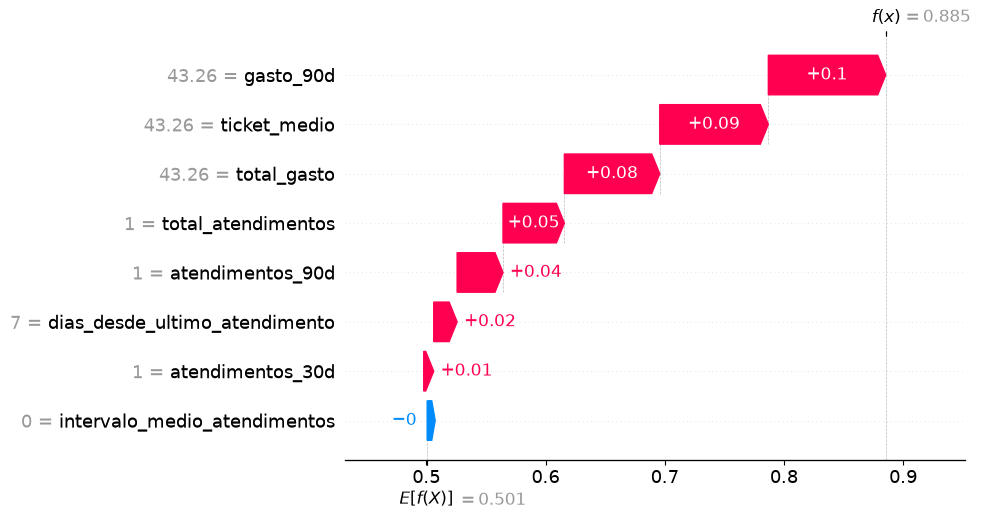

In [38]:
shap_explanation = shap.Explanation(
    values=shap_cliente,
    base_values=base_value,
    data=cliente.values,
    feature_names=cliente.index
)

shap.plots.waterfall(shap_explanation)

 Verificar a variável churn

In [40]:
print(df.columns.tolist())

['cliente_id', 'total_atendimentos', 'total_gasto', 'ticket_medio', 'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos', 'atendimentos_30d', 'atendimentos_90d', 'gasto_90d', 'quantidade_servicos_diferentes', 'quantidade_profissionais_diferentes', 'target_churn', 'atraso_vs_intervalo_medio', 'atraso_percentual']


In [41]:
print("y_train_a:")
print(y_train_a.value_counts())

print("\ny_test_a:")
print(y_test_a.value_counts())

y_train_a:
target_churn
0    261
1    139
Name: count, dtype: int64

y_test_a:
target_churn
0    65
1    35
Name: count, dtype: int64


In [42]:
print("Shape X:", X_a.shape)
print("Shape y:", y_train_a.shape)

print("\nValores do target:")
print(y_train_a.unique())

Shape X: (500, 8)
Shape y: (400,)

Valores do target:
[1 0]


In [43]:
features_churn = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d"
]

comparacao = df.groupby("target_churn")[features_churn].mean().T

display(comparacao)

target_churn,0,1
total_atendimentos,3.177914,2.057471
total_gasto,647.098681,357.464310
ticket_medio,138.518466,114.319885
dias_desde_ultimo_atendimento,33.481595,43.316092
intervalo_medio_atendimentos,32.786595,38.237414
atendimentos_30d,0.407975,0.287356
atendimentos_90d,1.141104,0.643678
gasto_90d,243.986595,104.608276


In [44]:
display(
    df.groupby("target_churn")[features_churn]
      .agg(["mean", "median", "min", "max"])
)

total_atendimentos                total_gasto                \
                           mean median min max        mean   median  min   
target_churn                                                               
0                      3.177914    2.0   0  14  647.098681  341.800  0.0   
1                      2.057471    2.0   0   9  357.464310  189.645  0.0   

                      ticket_medio           ... atendimentos_30d      \
                  max         mean   median  ...              min max   
target_churn                                 ...                        
0             3886.82   138.518466  138.025  ...                0   2   
1             2242.24   114.319885   98.005  ...                0   1   

             atendimentos_90d                  gasto_90d                \
                         mean median min max        mean   median  min   
target_churn                                                             
0                    1.141104    1.0   0   4  243.986595  124.220  0.0   
1                    0.643678    1.0   0   2  104.608276   34.175  0.0   

                       
                  max  
target_churn           
0             1807.73  
1              843.87  

[2 rows x 32 columns]

In [45]:
display(
    df.groupby("target_churn")[
        [
            "dias_desde_ultimo_atendimento",
            "gasto_90d",
            "total_atendimentos",
            "atendimentos_90d"
        ]
    ].median()
)

,dias_desde_ultimo_atendimento,gasto_90d,total_atendimentos,atendimentos_90d
target_churn,,,,
0,18.0,124.220,2.0,1.0
1,20.0,34.175,2.0,1.0


# Calibração de probabilidade

In [48]:
y_prob_d =  modelo_a.predict_proba(X_test_a)[:, 1]

prob_real, prob_predita = calibration_curve(
    y_test_a,
    y_prob_d,
    n_bins=10,
    strategy="uniform"
)

print("Probabilidade prevista:")
print(prob_predita)

print("\nFrequência real de churn:")
print(prob_real)

Probabilidade prevista:
[0.04571429 0.15729373 0.24692308 0.38495087 0.45426389 0.5515161
 0.626      0.73       0.85338654]

Frequência real de churn:
[0.07142857 0.5        0.23076923 0.28571429 0.5        0.55555556
 1.         1.         0.5       ]


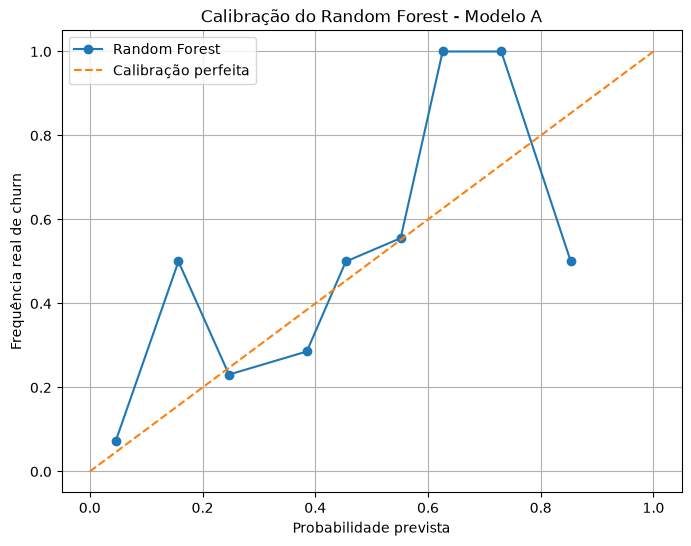

In [49]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_predita,
    prob_real,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibração perfeita"
)

plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência real de churn")
plt.title("Calibração do Random Forest - Modelo A")

plt.legend()
plt.grid()

plt.show()

In [50]:
from sklearn.metrics import brier_score_loss

brier_a = brier_score_loss(
    y_test_a,
    y_prob_d
)

print(f"Brier Score: {brier_a:.4f}")

Brier Score: 0.2016


In [51]:
from sklearn.metrics import brier_score_loss

prob_baseline = y_train_a.mean()

brier_baseline = brier_score_loss(
    y_test_a,
    [prob_baseline] * len(y_test_a)
)

print(f"Probabilidade baseline: {prob_baseline:.4f}")
print(f"Brier baseline: {brier_baseline:.4f}")
print(f"Brier Random Forest: {brier_a:.4f}")

Probabilidade baseline: 0.3475
Brier baseline: 0.2275
Brier Random Forest: 0.2016


Com base na compração usando brier_score_loss o Random Forest esta melhor que o baseline.

In [53]:
y_prob_d = modelo_d.predict_proba(X_test_a)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

resultados_threshold = []

for threshold in thresholds:
    y_pred = (y_prob_d >= threshold).astype(int)

    resultados_threshold.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_test_a,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_a,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_a,
            y_pred,
            zero_division=0
        )
    })
    
resultados_threshold = pd.DataFrame(resultados_threshold)

print(resultados_threshold)

    threshold  precision    recall        f1
0        0.10   0.377778  0.971429  0.544000
1        0.15   0.385542  0.914286  0.542373
2        0.20   0.387500  0.885714  0.539130
3        0.25   0.384615  0.857143  0.530973
4        0.30   0.386667  0.828571  0.527273
5        0.35   0.394366  0.800000  0.528302
6        0.40   0.409091  0.771429  0.534653
7        0.45   0.419355  0.742857  0.536082
8        0.50   0.428571  0.685714  0.527473
9        0.55   0.433962  0.657143  0.522727
10       0.60   0.785714  0.314286  0.448980
11       0.65   0.777778  0.200000  0.318182
12       0.70   0.833333  0.142857  0.243902
13       0.75   0.750000  0.085714  0.153846
14       0.80   0.500000  0.028571  0.054054
15       0.85   0.500000  0.028571  0.054054
16       0.90   0.000000  0.000000  0.000000


===== MATRIZ DE CONFUSÃO =====
[[29 36]
 [ 9 26]]


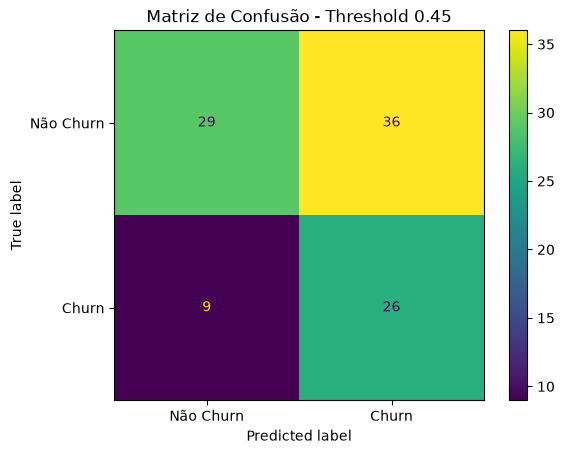

In [23]:
# Probabilidades previstas
y_proba = modelo_d.predict_proba(X_test_a)[:, 1]

# Threshold escolhido
threshold = 0.45

# Converter probabilidade em classe
y_pred_threshold = (y_proba >= threshold).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test_a, y_pred_threshold)

print("===== MATRIZ DE CONFUSÃO =====")
#print(y_pred_treshold)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Churn", "Churn"]
)

disp.plot()
plt.title(f"Matriz de Confusão - Threshold {threshold}")
plt.show()

In [24]:


# Matriz de confusão
cm = confusion_matrix(y_test_a, y_pred_threshold)

# Extrair valores
TN, FP, FN, TP = cm.ravel()

# Métricas
accuracy = accuracy_score(y_test_a, y_pred_threshold)
precision = precision_score(y_test_a, y_pred_threshold)
recall = recall_score(y_test_a, y_pred_threshold)
f1 = f1_score(y_test_a, y_pred_threshold)

# Especificidade
specificity = TN / (TN + FP)

# Exibir resultados
print("===== AVALIAÇÃO DO MODELO =====")
print(f"Threshold:    {threshold:.2f}")
print(f"TN:           {TN}")
print(f"FP:           {FP}")
print(f"FN:           {FN}")
print(f"TP:           {TP}")
print("--------------------------------")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")

===== AVALIAÇÃO DO MODELO =====
Threshold:    0.45
TN:           29
FP:           36
FN:           9
TP:           26
--------------------------------
Accuracy:     0.5500
Precision:    0.4194
Recall:       0.7429
F1 Score:     0.5361
Specificity:  0.4462


Usando os melhores parametros obtidos pelo GridSearchCV

In [13]:
 
param_grid_rf = {
    "n_estimators":[100, 200, 300],
    "max_depth": [None, 1, 2, 3, 5, 7],
    "min_samples_split": [2, 3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

In [14]:
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

In [15]:
grid_rf.fit(
    X_train_a,
    y_train_a
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 1, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-

In [16]:
print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("\nMelhor ROC-AUC:")
print(grid_rf.best_score_)

Melhores parâmetros:
{'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Melhor ROC-AUC:
0.6277149038941492


In [17]:
melhor_rf = grid_rf.best_estimator_

In [18]:
y_prob_rf = melhor_rf.predict_proba(X_test_a)[:, 1]

print(y_prob_rf[:10])

[0.55306052 0.55306052 0.55306052 0.55306052 0.55138324 0.54539455
 0.54605429 0.30917383 0.47076265 0.4143531 ]


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

resultados_threshold = []

for threshold in thresholds:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(
        y_test_a,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test_a,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_a,
        y_pred_threshold,
        zero_division=0
    )

    resultados_threshold.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold

,Threshold,Precision,Recall,F1
0,0.10,0.350000,1.000000,0.518519
1,0.15,0.350000,1.000000,0.518519
2,0.20,0.353535,1.000000,0.522388
3,0.25,0.343750,0.942857,0.503817
4,0.30,0.354839,0.942857,0.515625
5,0.35,0.366667,0.942857,0.528000
6,0.40,0.383721,0.942857,0.545455
7,0.45,0.397436,0.885714,0.548673
8,0.50,0.397059,0.771429,0.524272
9,0.55,0.377358,0.571429,0.454545


In [20]:
melhor_threshold = df_threshold.loc[
    df_threshold["F1"].idxmax()
]

melhor_threshold

Threshold    0.450000
Precision    0.397436
Recall       0.885714
F1           0.548673
Name: 7, dtype: float64

In [21]:
df_threshold.sort_values(
    by="F1",
    ascending=False
)

,Threshold,Precision,Recall,F1
7,0.45,0.397436,0.885714,0.548673
6,0.40,0.383721,0.942857,0.545455
5,0.35,0.366667,0.942857,0.528000
8,0.50,0.397059,0.771429,0.524272
2,0.20,0.353535,1.000000,0.522388
0,0.10,0.350000,1.000000,0.518519
1,0.15,0.350000,1.000000,0.518519
4,0.30,0.354839,0.942857,0.515625
3,0.25,0.343750,0.942857,0.503817
9,0.55,0.377358,0.571429,0.454545


In [22]:
from sklearn.metrics import confusion_matrix

y_pred_final = (y_prob_rf >= 0.45).astype(int)

cm = confusion_matrix(y_test_a, y_pred_final)

print(cm)

[[18 47]
 [ 4 31]]


Random Forest tunado + threshold 0.45.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

# Modelo tunado
melhor_rf = grid_rf.best_estimator_

# Probabilidades
y_prob_rf = melhor_rf.predict_proba(X_test_a)[:, 1]

# Threshold escolhido
threshold = 0.45

# Classificação usando threshold
y_pred_rf = (y_prob_rf >= threshold).astype(int)

# Métricas
accuracy = accuracy_score(y_test_a, y_pred_rf)
precision = precision_score(y_test_a, y_pred_rf, zero_division=0)
recall = recall_score(y_test_a, y_pred_rf, zero_division=0)
f1 = f1_score(y_test_a, y_pred_rf, zero_division=0)
roc_auc = roc_auc_score(y_test_a, y_prob_rf)
brier = brier_score_loss(y_test_a, y_prob_rf)

# Matriz
cm = confusion_matrix(y_test_a, y_pred_rf)

print("========================================")
print("AVALIAÇÃO FINAL - RANDOM FOREST")
print("========================================")

print(f"Threshold: {threshold}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Brier:     {brier:.4f}")

print("\nMatriz de Confusão:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test_a,
    y_pred_rf,
    zero_division=0
))

AVALIAÇÃO FINAL - RANDOM FOREST
Threshold: 0.45
Accuracy:  0.4900
Precision: 0.3974
Recall:    0.8857
F1:        0.5487
ROC-AUC:   0.5818
Brier:     0.2443

Matriz de Confusão:
[[18 47]
 [ 4 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.28      0.41        65
           1       0.40      0.89      0.55        35

    accuracy                           0.49       100
   macro avg       0.61      0.58      0.48       100
weighted avg       0.67      0.49      0.46       100

